# 2023년 의료기관별 시군구별 진료비 분석

## 단계: 03. 통계적 가설 검정 (Statistical Testing)
- 목표: 지역별 진료비 차이의 통계적 유의성을 검증하고, 데이터의 특성(비정규성)에 맞는 분석 방법론을 확정한다.

### 3.1 환경 설정 및 분석 준비
- 검정에 필요한 라이브러리를 로드하고 기초적인 파생 변수를 생성합니다.
- 사용 도구: scipy.stats, itertools, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from scipy.stats import rankdata
from itertools import combinations
import seaborn as  sns

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df = pd.read_csv(r'C:\data\hira_sigungu_2023.csv', encoding='cp949')

In [2]:
df['1인당_진료비_만원'] = (df['요양급여비용총액(선별포함)'] / df['환자수'] / 10000).round(1)

x = df['1인당_진료비_만원']
print(f'데이터 개수 : {len(x)}개')

데이터 개수 : 251개


### 3.2 [검정 1] 데이터 분포 분석 및 정규성 검정
모수 검정(T-test, ANOVA)을 사용할지, 비모수 검정을 사용할지 결정하기 위해 정규성을 확인합니다.
- 분석 항목: 왜도/첨도 확인, Shapiro-Wilk 검정, Q-Q Plot 시각화
- 추가 분석: 로그 변환(log1p)을 통한 분포 개선 여부 확인

In [3]:
# 1. 왜도, 첨도 확인
skewness = stats.skew(x)
kurtosis = stats.kurtosis(x)
print(f'왜도(Skewness): {skewness:.3f}')
print(f'첨도(Kurtosis): {kurtosis:.3f}')
print()
#해석기준
# 왜도 : |값| < 0.5 대칭적
# 첨도 : 0에 가까울수록 정규분포

왜도(Skewness): 1.619
첨도(Kurtosis): 7.947



In [4]:
# 2. Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(x)
print(f'W 통계량: {sw_stat:.4f}')
print(f'p값: {sw_p:.6f}')
if sw_p < 0.05:
    print('정규성 기각 (비모수 검정 사용)')
else:
    print('정규성 지지 (모수 검정 가능)')

W 통계량: 0.9136
p값: 0.000000
정규성 기각 (비모수 검정 사용)


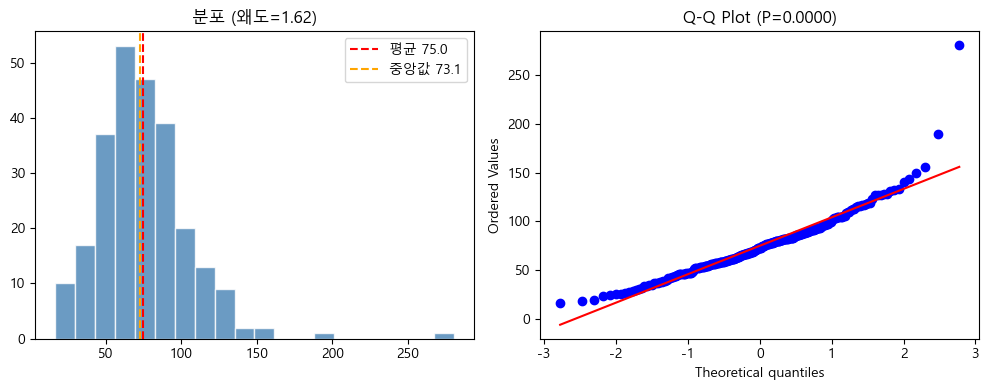

In [5]:
# 3. Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 히스토그램
axes[0].hist(x, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x.mean(), color='red', ls='--', label=f'평균 {x.mean():.1f}')
axes[0].axvline(x.median(), color='orange', ls='--', label=f'중앙값 {x.median():.1f}')
axes[0].set_title(f'분포 (왜도={skewness:.2f})')
axes[0].legend()

# Q-Q Plot
stats.probplot(x, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot (P={sw_p:.4f})')

plt.tight_layout()
plt.savefig('normality.png', dpi=150)
plt.show()

In [6]:
# 4. 로그 변환 후 재검정
x_log = np.log1p(x)
sw_stat2, sw_p2 = stats.shapiro(x_log)
sk2 = stats.skew(x_log)
print(f'\n[로그 변환 후]')
print(f'왜도: {sk2:.3f}')
print(f'SW p값: {sw_p2:.6f}')


[로그 변환 후]
왜도: -0.512
SW p값: 0.000265


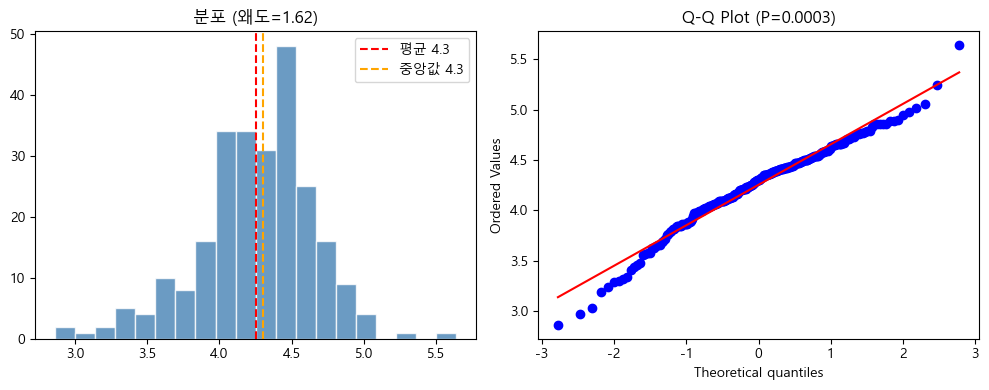

In [7]:
# 3. Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 히스토그램
axes[0].hist(x_log, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x_log.mean(), color='red', ls='--', label=f'평균 {x_log.mean():.1f}')
axes[0].axvline(x_log.median(), color='orange', ls='--', label=f'중앙값 {x_log.median():.1f}')
axes[0].set_title(f'분포 (왜도={skewness:.2f})')
axes[0].legend()

# Q-Q Plot
stats.probplot(x_log, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot (P={sw_p2:.4f})')

plt.tight_layout()
plt.show()

>**출력 결과 읽기**

>**왜도 (Skewness)**
1.619<br>
기준: |값| < 0.5 → 대칭<br>
1.619 → 오른쪽 꼬리 분포<br>
소수 시군구가 극단적 고값<br>

>**첨도 (Kurtosis, excess)**
7.947<br>
기준: 0에 가까울수록 정규<br>
7.947 → 매우 뾰족한 분포<br>
극단 이상치(화순군 등) 영향<br>

>**Shapiro-Wilk p값 (원본)**
< 0.0001<br>
p < 0.05 → 정규성 기각<br>
결론: 비모수 검정 사용<br>
(Mann-Whitney, KW, Spearman)<br>

>**Shapiro-Wilk p값 (로그변환)**
0.0003<br>
여전히 p < 0.05 → 기각<br>
하지만 왜도 -0.51로 크게 개선<br>
회귀분석 투입 시 로그 사용 권장<br>

>**정리**<br>
데이터 개수: 251개<br>
왜도(Skewness): 1.619     # 양수 → 오른쪽 꼬리<br>
첨도(Kurtosis): 7.947     # 크다 → 뾰족하고 꼬리가 두꺼움<br>
W 통계량: 0.9136           # 1에 가까울수록 정규분포<br>
p값:      0.000000         # 0.05보다 작으면 정규성 기각<br>
→ 정규성 기각 (비모수 검정 사용)<br>
[로그 변환 후]<br>
왜도: -0.512               # 절대값이 0.5에 가까워짐 → 개선<br>
SW p값: 0.000265           # 여전히 기각이지만 많이 나아짐<br>

>**차트 읽기**

>**히스토그램 (원본)** — 왜도 1.619<br>
막대가 왼쪽에 몰려 있고 오른쪽으로 긴 꼬리가 이어집니다. 평균 중앙값보다 오른쪽에 있습니다. 이것이 양의 왜도(오른쪽 꼬리)의 전형적 모습입니다.

>**Q-Q Plot (원본)** — 점들이 선에서 벗어남<br>
정규분포라면 모든 점이 빨간 대각선 위에 놓여야 합니다. 오른쪽 끝에서 점들이 선보다 위로 크게 이탈하면 오른쪽 꼬리가 두껍다는 증거입니다 (화순군 등 이상치). Q-Q Plot이 선에서 S자 형태로 벗어나면 왜도가 있다는 신호입니다.

>**로그 변환 후** — 훨씬 대칭적으로 변환<br>
히스토그램이 종 모양에 가까워지고, Q-Q Plot 점들이 선 근처에 모입니다. 왜도가 1.619 → -0.512로 줄었습니다. 완전한 정규분포는 아니지만 회귀분석 투입 변수로는 로그 변환 값을 사용하는 것이 적절합니다.

>⑥ **결과 요약표** — 변환 전후 비교<br>
왜도: 1.619 → -0.512 (크게 개선), SW p값: <0.0001 → 0.0003 (기각은 유지되나 개선), KS p값은 0.13 → 0.24로 오히려 더 좋아졌습니다. KS 검정은 소표본에서 덜 민감해서 이런 차이가 생깁니다.

>**Memo**<br>
Q-Q Plot에서 점들이 빨간 선과 일치할수록 정규분포에 가깝습니다.
히스토그램이 좌우 대칭 종 모양일수록 정규분포에 가깝습니다.
박스플롯에서 이상치가 없고 박스가 중앙에 균형 잡혀 있을수록 정규분포에 가깝습니다.

>**최종 결론**<br>
1인당 진료비는 정규분포를 따르지 않습니다 (Shapiro-Wilk p < 0.0001, 왜도 1.619).<br>
→ 이후 모든 그룹 비교 검정은 비모수 방법을 사용합니다.<br>
→ 회귀분석 투입 시에는 로그 변환을 적용합니다.<br>

### 정규성 결과에 따른 분석 방법 결정 기준

| 분석 목적 | 정규성 충족 시 (모수 검정) | 정규성 기각 시 (비모수 검정) |
| :--- | :--- | :--- |
| **2그룹 비교** | t-검정 (t-test) | Mann-Whitney U 검정 |
| **다그룹 비교** | One-way ANOVA (분산분석) | Kruskal-Wallis 검정 |
| **사후검정** | Tukey HSD | Dunn + Bonferroni 보정 |
| **상관분석** | Pearson $r$ (피어슨) | Spearman $\rho$ (스피어먼) |
| **회귀분석** | OLS 직접 투입 | 로그 변환 후 OLS |

> **Note:** 정규성 기각 시에는 데이터의 분포를 정규분포에 가깝게 만들기 위해 **로그 변환(Log Transformation)** 등의 데이터 전처리를 수행하거나, 순위 기반의 **비모수 검정**을 실시합니다.

### [검정 2] 광역시 여부에 따른 진료비 차이 검정 (비모수 2그룹)
광역시와 비광역시 간에 1인당 진료비 지출 패턴에 유의미한 차이가 있는지 검정합니다.
- 방법론: Mann-Whitney U Test (비모수 독립표본 검정)
- 핵심 지표: p-value, 효과크기(r)

In [8]:
# 광역시 구분 변수생성
metro = ['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종']
df['광역시'] = df['시도'].isin(metro).astype(int)

In [9]:
# 1. 그룹별 기술통계
g1 = df[df['광역시']==1]['1인당_진료비_만원']
g2 = df[df['광역시']==0]['1인당_진료비_만원']

print('=== 광역시 ===')
print(f'n : {len(g1)}')
print(f'평균 : {g1.mean():.1f} 만원')
print(f'중앙값 : {g1.median():.1f} 만원')
print(f'표준편차 : {g1.std():.1f}')

print('=== 비광역시 ===')
print(f'n : {len(g2)}')
print(f'평균 : {g2.mean():.1f} 만원')
print(f'중앙값 : {g2.median():.1f} 만원')
print(f'표준편차 : {g2.std():.1f}')

=== 광역시 ===
n : 76
평균 : 82.0 만원
중앙값 : 81.0 만원
표준편차 : 28.8
=== 비광역시 ===
n : 175
평균 : 72.0 만원
중앙값 : 67.8 만원
표준편차 : 30.7


In [10]:
# 2. Mann-Whitney U 검정
# alternative='two-sided': 양측 검정
# (어느 쪽이 높은지 방향 모를 때)
u_stat, p_val = stats.mannwhitneyu(
    g1, g2,
    alternative='two-sided'
)

print(f'\nU 통계량: {u_stat:.0f}')
print(f'p값 : {p_val:.6f}')

if p_val < 0.05:
    print('→ 귀무가설 기각')
    print(' 광역시와 비광역시 진료비에')
    print(' 유의미한 차이가있다 (p<0.05)')
else:
    print('→ 귀무가설 채택 실패')


U 통계량: 8176
p값 : 0.003895
→ 귀무가설 기각
 광역시와 비광역시 진료비에
 유의미한 차이가있다 (p<0.05)


In [11]:
# 3. 효과 크기 (r)
# r = |Z| / sqrt(N)
# 0.1=소, 0.3=중, 0.5=대

n1, n2 = len(g1), len(g2)
z = stats.norm.ppf(p_val / 2)
r = abs(z) / np.sqrt(n1 + n2)

print(f'\n효과크기 r: {r:.4f}')
if r < 0.1:
    print('→ 작은효과 (Small)')
elif r < 0.3:
    print('→ 중간 효과 (Medium)')
else:
    print('→ 큰 효과 (Large)')


효과크기 r: 0.1822
→ 중간 효과 (Medium)


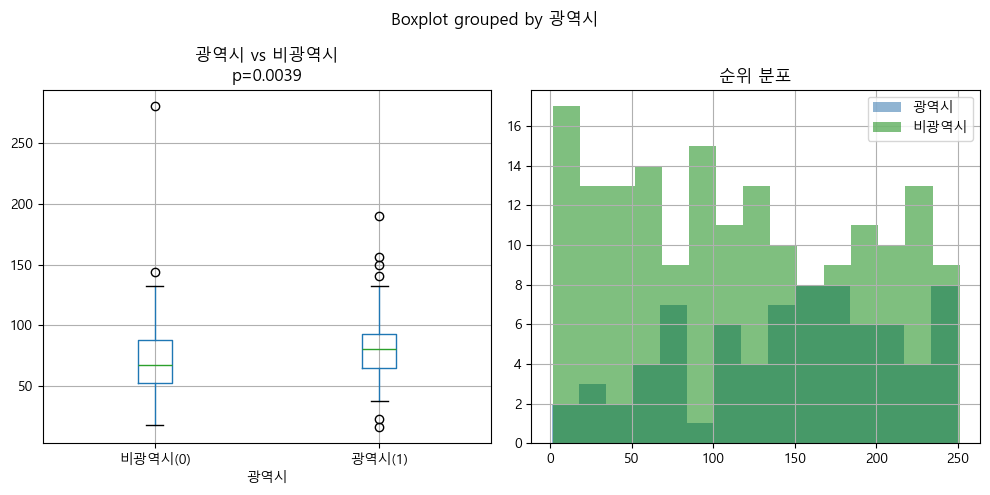

In [12]:
# 4. 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 박스플롯
df.boxplot(
    column='1인당_진료비_만원',
    by='광역시',
    ax=axes[0]
)
axes[0].set_title(
    f'광역시 vs 비광역시\np={p_val:.4f}')
axes[0].set_xticklabels(
    ['비광역시(0)','광역시(1)'])

# 순위 분포
from scipy.stats import rankdata
df['rank'] = rankdata(
    df['1인당_진료비_만원'])
df[df['광역시']==1]['rank'].hist(
    bins=15, ax=axes[1],
    color='steelblue', alpha=0.6,
    label='광역시')
df[df['광역시']==0]['rank'].hist(
    bins=15, ax=axes[1],
    color='green', alpha=0.5,
    label='비광역시')
axes[1].set_title('순위 분포')
axes[1].legend()

plt.tight_layout()
plt.savefig('mw_result.png', dpi=150)
plt.show()

> **결과 읽기**

> **결과**: 광역시(중앙값81.0만원)가 비광역시(67.8만원)보다 유의미하게 높습니다. (U=8,176, p=0.0039)<br>
> 효과크기 r=0.182는 소~중간 수준으로, 시군구 내 변동성(표준편차 ~30만원)이 그룹 간 차이(13.2만원)보다
> 더 크다는 의미입니다. 이 데이터에서는 광역시/비광역시 구분보다 개별 시군구의 특성(대학병원 유무 등)이 진료비를 더 잘 설명합니다.

> **효과크기 r** : 0.1 ~ 0.3 → 소~중간 효과<br>
> 통계적 유의성은 있으나 실질 차이는 작음

> **중앙값 차이** : 13.2만원 <br>
> 광역시 81.0 vs 비광역시 67.8 <br>
> 연간 약 132,000원 차이

> **U 통계량 읽기** <br>
> U = 8,176이란, 광역시-비광역시 모든 쌍(76x175=13,300쌍)을 비교했을 때 광역시가 더 높은 경우가 8,176번이라는 뜻입니다. 50%인 6,650번보다 많으므로 광역시가 전반적으로 더 높은 분포입니다.

> **주의** <br>
> p=0.0039로 유의하지만 효과 크기 r=0.182는'소 ~ 중간' 수준입니다. 중앙값 차이도 13.2만원으로, 양그룹 내 변동성(표준편차 ~ 30만원)에 비해 크지 않습니다.

> **박스플롯** - 두 그룹 중앙값, 분포 비교 <br>
> 박스의 중앙값이 광역시(81.0)가 비광역시(67.8)보다 높게 위치합니다. 두 박스가 겹치는 부분이 많다는 것도 중요합니다. 겹침이 많을수록 두 그룹이 완전히 분리되지 않아 효과 크기가 작습니다. 오른쪽 이상치는 화순군, 부산서구 등입니다.

> **KDE분포** - 두 그룹의 분포 형태 비교 <br>
> 파란색(광역시)과 초록색(비광역시)곡선이 많이 겹쳐 있습니다. 광역시 곡선이 약간 오른쪽에 위치하지만, 비광역시에서도 높은 진료비 시군구가 있어 완전히 분리되지 않습니다.

> **순위 분포** - Mann-Whitney의 실제 검정 근거 <br>
> Mann-Whitney는 원래 값이 아닌 순위를 씁니다. 광역시(파란색)의 순위 분포가 비광역시(초록색)보다 오른쪽(높은 순위)에 약간 더 치우쳐 있습니다. 광역시 평균순위 146.1 vs 비광역시 117.3 이 차이가 U통계량과 p값의 기반입니다.

> **시각화에서 가장 먼저 볼 것** <br>
> 박스플롯에서 두 박스가 겹치는 정도를 봅니다. 겹침이 없으면 효과 크기가 크고, 이 데이터처럼 많이 겹치면 효과 크기가 작습니다. p값은 작아도 박스가 많이 겹치면 '통계적으로 유의하나 실질 차이는 작다'는 결론입니다.

> **결론 요약** <br>
> 1. 광역시(중앙값 81.0만원)가 비광역시(67.8만원)보다 1인당 진료비가 높습니다.
> 2. 이 차이는 통계적으로 유의합니다. (=8,176, p=0.0039)
> 3. 그러나 효과 크기 r=0.182는 소 ~ 중간 수준으로, 시도 구분만으로 진료비를 완전히 설명하기는 어렵습니다.

### 3.4 [검정 3] 17개 시도별 진료비 차이 분석 (비모수 다그룹)
광역지자체(시도)별로 진료비 분포가 모두 동일한지, 아니면 특정 지역에서 차이가 발생하는지 확인합니다.
- 방법론: Kruskal-Wallis Test
- 핵심 지표: H 통계량, 효과 크기(η2)

In [13]:
# Kruskal-Wallis
# k개 그룹 동시 비교 - 17개 시도를 한 번에
# H0 : 17개 시도의 1인당 진료비 분포가 모두 같다
# H1 : 적어도 한 쌍 이상의 시도 간 분포가 다르다

# 1. 시도별 기술통계
sido_stat = df.groupby('시도')[
    '1인당_진료비_만원'].agg(
        n='count',
        median='median',
        mean='mean',
        std='std'
    ).round(1).sort_values(
        'median', ascending=False)
print('시도별 기술통계 (중앙값 내림차순):')
print(sido_stat)

시도별 기술통계 (중앙값 내림차순):
     n  median  mean   std
시도                        
전북  15    96.8  83.5  35.2
광주   5    89.0  92.7  24.1
부산  16    84.4  85.7  32.0
인천  10    81.6  76.4  28.0
서울  25    81.5  83.1  25.3
경남  22    80.8  81.2  23.0
제주   2    77.8  77.8  36.6
전남  22    76.7  87.1  48.9
대구   9    72.5  75.8  34.5
세종   1    72.4  72.4   NaN
울산   5    69.7  84.2  41.4
경기  42    68.2  70.2  21.7
충남  16    66.6  68.6  20.1
충북  14    63.6  66.1  21.2
경북  24    62.4  65.2  26.0
대전   5    60.1  76.7  30.9
강원  18    45.5  52.7  33.7


In [14]:
# 2. Kruskal-Wallis 검정
# 시도별로 데이터를 리스트로 분리
groups = [
    g['1인당_진료비_만원'].values
    for _, g in df.groupby('시도')
]
print(f'\n그룹 수 : {len(groups)}개')


그룹 수 : 17개


In [15]:
# KW 검정 실행
h_stat, p_val = stats.kruskal(*groups)
# *groups = 리스트를 개별 인자로 풀기

print(f'\nH통계량: {h_stat:.4f}')
print(f'자유도   : {len(groups)-1}')
print(f'p값      : {p_val:.6f}')
if p_val < 0.05:
    print('→ 귀무가설 기각')
    print(' 시도 간 유의미한 차이 있음')


H통계량: 30.8850
자유도   : 16
p값      : 0.013919
→ 귀무가설 기각
 시도 간 유의미한 차이 있음


In [16]:
# 3. 효과 크기 η²
# η² = (H - k + 1) / (N - k)
# 0.01=소, 0.06=중, 0.14=대

N = len(df)
K = len(groups)
eta2 = (h_stat - K + 1) / (N - K)

print(f'\n효과 크기 η²: {eta2:.4f}')
if eta2 < 0.01:
    print('→ 작은 효과 (Small)')
elif eta2 < 0.06:
    print('→ 소 ~ 중간 효과')
elif eta2 < 0.14:
    print('→ 중간 효과 (Medium)')
else:
    print('→ 큰 효과 (Large)')


효과 크기 η²: 0.0636
→ 중간 효과 (Medium)


In [17]:
# 4. 시도별 평균 순위
# KW가 실제로 쓰는 값을 직접 확인
df['rank'] = rankdata(
    df['1인당_진료비_만원'])

mean_rank = df.groupby('시도')[
    'rank'].mean().sort_values(
        ascending=False).round(1)

print('\n시도별 평균 순위:')
print(mean_rank)
print(f'\n전체 평균 순위: {df['rank'].mean():.1f}')


시도별 평균 순위:
시도
광주    180.1
부산    154.3
서울    151.0
전북    149.0
경남    147.8
인천    140.2
전남    140.1
울산    131.8
제주    131.2
대구    127.6
대전    125.0
세종    123.0
경기    114.0
충남    110.6
충북    106.6
경북    102.9
강원     65.1
Name: rank, dtype: float64

전체 평균 순위: 126.0


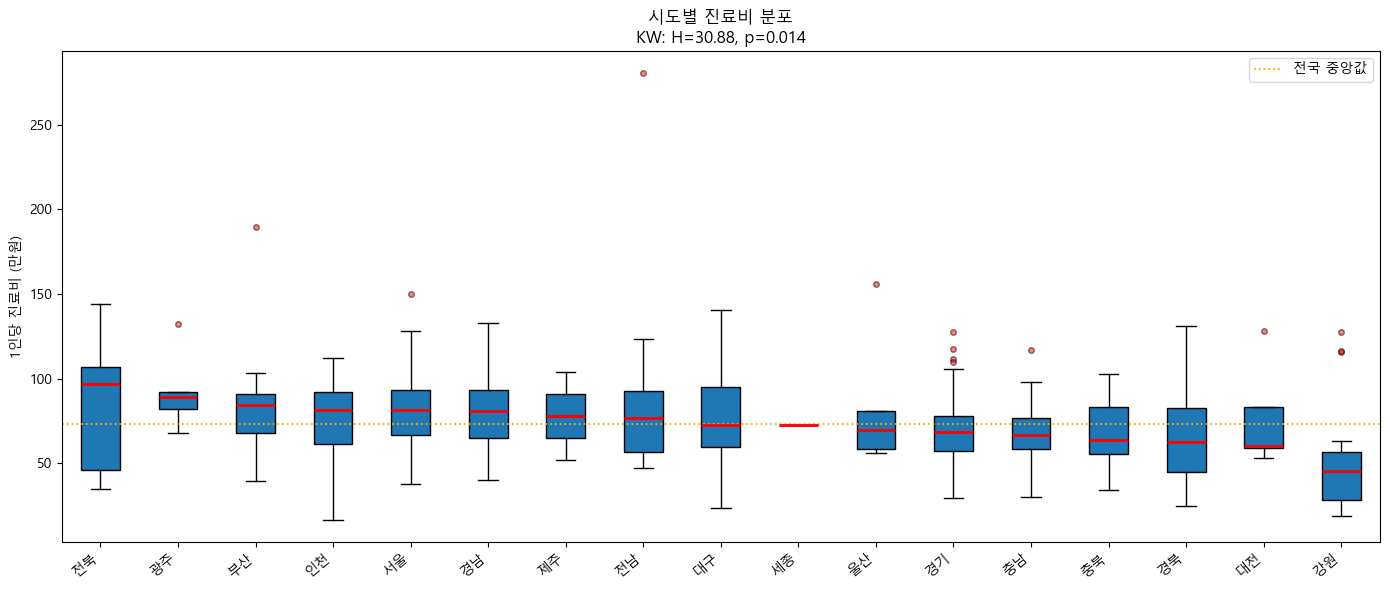

In [18]:
# 5. 시각화
sido_order = (df.groupby('시도')[
    '1인당_진료비_만원']
              .median()
              .sort_values(ascending=False)
              .index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
data_list = [
    df[df['시도']==s][
        '1인당_진료비_만원'].values
    for s in sido_order
]

bp = ax.boxplot(data_list,
                patch_artist=True,
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='o',
                                markersize=4, alpha=0.5,
                                markerfacecolor='red'))

ax.set_xticks(range(1,len(sido_order)+1))
ax.set_xticklabels(
    sido_order, rotation=40, ha='right')
ax.set_ylabel('1인당 진료비 (만원)')
ax.set_title(
    f'시도별 진료비 분포\n'
    f'KW: H={h_stat:.2f}, p={p_val:.3f}')
ax.axhline(
    df['1인당_진료비_만원'].median(),
    color='orange', ls=':', lw=1.3,
    label='전국 중앙값')
ax.legend()
plt.tight_layout()
plt.savefig('kw_result.png', dpi=150)
plt.show()

>**결과해석**<br>

> **H 통계량** - 30.885 <br>
: 자유도=16 (k-1=17-1), χ² 분포 기반 — 클수록 차이 큼<br>
> **p값** - 0.014<br>
: p < 0.05 → 귀무가설 기각, 시도 간 유의한 차이 존재<br>
> **효과 크기 η²** - 0.064<br>
: 중간(Medium) 효과, 시도 변수가 진료비의 6.4% 설명<br>
> **강원 평균순위** - 65.1위<br>
: 전체 평균 126위와 크게 차이, 가장 낮은 순위 → 이상치<br>

> **η² = 0.064** 해석 추가 <br>
> 시도라는 변수가 1인당 진료비 변동의 6.4%만 설명합니다. 나머지 93.6%는 시도 내 시군구 특성(대형병원 유무, 인구 구조 등)에서 옵니다. "시도별로 차이가 있다"(p=0.014)는 사실이지만,<br>
"시도 구분이 진료비를 잘 예측한다"는 아닙니다. (통계적 유의성 ≠ 설명력)<br>
(4단계 회귀분석에서 대형병원 유무, 내원일수 등 시군구 단위 변수를 추가해야 설명력이 올라갈 수 있다.)

> **Kruskal-Wallis 검정 핵심 요약**<br>
**결과** — H=30.885, p=0.014로 17개 시도 간 1인당 진료비에 통계적으로 유의한 차이가 있습니다.<br>
평균순위를 보면 강원도(65.1위)만 전체 평균(126위)에서 크게 이탈하고, 나머지 16개 시도는 서로 비슷한 수준입니다. H값을 높이는 주범이 강원도라는 뜻입니다.<br>
(Dunn 사후검정에서 "강원도 vs 서울·부산·경남" 3쌍만 유의하게 나오는 이유가 될 수 있다.)

> **차트 읽기**<br>
> **시도별 박스플롯** — 분포 전체를 한눈에 보기 <br>
박스의 빨간 중앙선(중앙값) 위치가 시도마다 다릅니다. 강원도 박스가 가장 아래에, 전북·광주·부산이 상위권입니다. 박스 크기(IQR)을 살펴보면 전남은 박스가 크고(시군구 간 격차 큼), 경기·충남은 작습니다(시군구 간 비교적 균등). 오른쪽으로 튀어나온 빨간 점은 이상치로, 전남 280.6만원이 가장 극단적입니다.

> **시도별 중앙값 막대** — 순위 직관적 비교<br>
막대가 길수록 1인당 진료비 중앙값이 높습니다. 전국 중앙값 기준선을 기준으로 어느 시도가 위아래에 위치하는지 확인합니다. 강원도가 45.5만원으로 압도적으로 낮다는 것이 눈에 바로 들어옵니다.

> **시도별 평균순위** — KW 검정의 실제 기반<br>
KW는 원래 값이 아닌 순위를 씁니다. 전체 251개 시군구의 평균 순위는 126위입니다. 광주(180.1위)·부산(154.3위)이 평균보다 훨씬 높고, 강원(65.1위)이 크게 낮습니다. H 통계량은 이 "평균 순위의 편차 합산"에서 나옵니다. 강원도가 유독 낮은 것이 H값을 높이는 핵심 원인입니다.

### 3.5 [검정 4] 시도 간 사후 검정 (Post-hoc Analysis)
Kruskal-Wallis 검정 결과 유의미한 차이가 발견됨에 따라, 구체적으로 어떤 시도 쌍에서 차이가 나는지 분석합니다.
- 방법론: Dunn's Test + Bonferroni Correction
- 핵심 발견: 강원도 지역의 특수성(타 시도와의 유의미한 차이) 확인

In [19]:
# 1. 순위 및 그룹 정보
N = len(df)
df['rank'] = rankdata(df['1인당_진료비_만원'])

n_i = df.groupby('시도')['rank'].count() #그룹n
r_i = df.groupby('시도')['rank'].mean() # 평균순위

print(f'총 시군구: {N}')
print(f'전체 평균 순위: {df['rank'].mean():.1f}')
print(f'\n시도별 평균순위 (상위 5):')
print(r_i.sort_values(ascending=False).head())

총 시군구: 251
전체 평균 순위: 126.0

시도별 평균순위 (상위 5):
시도
광주    180.100000
부산    154.281250
서울    151.040000
전북    148.966667
경남    147.818182
Name: rank, dtype: float64


In [20]:
# 2. 모든 쌍 Dunn 검정
sidos = n_i.index.tolist()
pairs = list(combinations(sidos, 2))
m = len(pairs) # 136쌍
print(f'\n비교 쌍 수: {m}')
print(f'Bonferroni 보정 α: {0.05/m:.6f}')

results = []
for g1, g2 in pairs:
    ni, nj = n_i[g1], n_i[g2]
    ri, rj = r_i[g1], r_i[g2]

    #표준오차
    se = np.sqrt(
    (N*(N+1)/12) * (1/ni + 1/nj))

    # Z 통계량
    z = (ri - rj) / se

    # p값 계산
    p_raw = 2 * (1-stats.norm.cdf(abs(z)))
    p_bon = min(p_raw * m, 1.0)

    results.append({
    '시도1' : g1, '시도2' : g2,
    'Z통계량': round(z, 3),
    'p_raw': round(p_raw, 4),
    'p_Bonf': round(p_bon, 4),
    '유의': p_bon < 0.05
    })
dunn_df = pd.DataFrame(results)


비교 쌍 수: 136
Bonferroni 보정 α: 0.000368


In [21]:
# 3. 결과 확인
# 유의한 쌍만 출력
sig = dunn_df[dunn_df['유의']].sort_values(
    'p_Bonf')
print(f'\n유의한 쌍 ({len(sig)}개):')
print(sig[['시도1', '시도2', 'Z통계량',
           'p_raw', 'p_Bonf']])

# 전체 결과 저장
dunn_df.to_csv('dunn_result.csv',
               index=False,
               encoding='utf-8-sig')


유의한 쌍 (3개):
  시도1 시도2   Z통계량   p_raw  p_Bonf
7  강원  서울 -3.829  0.0001  0.0175
1  강원  경남 -3.584  0.0003  0.0460
6  강원  부산 -3.575  0.0004  0.0477


In [22]:
# 4. 특정 시도 집중 분석
# 강원 관련 쌍만 필터링
gw_pairs = dunn_df[
    (dunn_df['시도1']=='강원') |
    (dunn_df['시도2']=='강원')
    ].copy()

# 상대 시도명 정리
gw_pairs['상대시도'] = gw_pairs.apply(
    lambda r: r['시도2']
    if r['시도1']=='강원'
    else r['시도1'], axis=1)

gw_pairs = gw_pairs.sort_values('p_Bonf')
print('\n강원 vs 각 시도:')
print(gw_pairs[['상대시도', 'Z통계량',
                'p_raw', 'p_Bonf',
                '유의']].to_string())


강원 vs 각 시도:
   상대시도   Z통계량   p_raw  p_Bonf     유의
7    서울 -3.829  0.0001  0.0175   True
1    경남 -3.584  0.0003  0.0460   True
6    부산 -3.575  0.0004  0.0477   True
12   전북 -3.304  0.0010  0.1297  False
11   전남 -3.251  0.0011  0.1561  False
3    광주 -3.133  0.0017  0.2353  False
0    경기 -2.390  0.0168  1.0000  False
2    경북 -1.671  0.0947  1.0000  False
4    대구 -2.107  0.0351  1.0000  False
5    대전 -1.632  0.1027  1.0000  False
8    세종 -0.776  0.4377  1.0000  False
9    울산 -1.817  0.0692  1.0000  False
10   인천 -2.622  0.0087  1.0000  False
13   제주 -1.222  0.2216  1.0000  False
14   충남 -1.823  0.0683  1.0000  False
15   충북 -1.603  0.1090  1.0000  False


> **결과** -136쌍 중 단 3쌍만 유의 <br>
> 총 비교 쌍 - 136쌍 <br>
: C(17,2) = 17×16÷2 <br>
> **유의한 쌍** - 3쌍 <br>
: 모두 강원도 포함 <br>
> **임계 |Z|값** - 3.562 <br>
: Bonferroni 기준 0.05÷136 <br>

> **해석** <br>
> 136쌍 중 유의한 쌍이 단 3개이고 모두 강원도가 포함됩니다. 서울·부산·경남 등 나머지 시도 간에는 통계적으로 차이가 없습니다. KW p=0.014를 만든 주된 원인이 강원도 1개 시도임이 Dunn 검정을 통해 밝혀진 것입니다.<br>
> Bonferroni 보정 — 강원 vs 전북의 p_raw=0.001은 보통 기준으로는 유의하지만, 보정 후 p_bon=0.130으로 탈락합니다. 다중비교 상황에서 보정 없이 p_raw만 보면 잘못된 결론을 내릴 수 있습니다.<br>
> EDA에서 강원도가 낮아 보인다고 관찰 → KW에서 "시도 간 차이 있음" 확인 → Dunn에서 "강원도가 서울·부산·경남과 유의하게 다름 확인<br>

> **정리** <br>
> 1. 모두 강원도 관련 쌍 — 강원 vs 서울(p=0.018), 강원 vs 경남(p=0.046), 강원 vs 부산(p=0.048).
> 2. 17개 시도 간 136쌍 중 통계적으로 유의한 쌍은 단 3쌍으로, 나머지 16개 시도 간에는 Bonferroni 보정 후 통계적 차이가 없습니다.

### 3.6 [검정 5] 변수 간 상관관계 분석 (Correlation)
1인당 진료비와 밀접한 연관이 있는 독립변수를 탐색하여 모델링 후보군을 선정합니다.
- 방법론: Spearman Rank Correlation (이상치 영향 최소화)
- 비교: Pearson 상관계수와의 차이 분석을 통한 이상치 영향 재확인

In [23]:
df['1인당_내원일수'] = (
    df['입내원일수']
    / df['환자수']).round(2)
df['보험자부담률'] = (
    df['보험자부담금(선별포함)']
    / df['요양급여비용총액(선별포함)']
    * 100).round(1)

In [24]:
# 1. Spearman 상관
x = df['1인당_내원일수']
y = df['1인당_진료비_만원']

rho, p_val = stats.spearmanr(x, y)

print(f'Spearman ρ: {rho:.4f}')
print(f'p값: {p_val:.6f}')
print()

# 해석
if p_val < 0.05:
    print(f'→유의한 {'양' if rho>0 else '음'}의 상관관계')
    if abs(rho) < 0.2: strength='약함'
    elif abs(rho) < 0.4: strength='중간'
    elif abs(rho) < 0.6: strength='강함'
    else: strength='매우강함'
    print(f'→강도: {strength} (|ρ|={abs(rho):.3f})')

Spearman ρ: 0.3451
p값: 0.000000

→유의한 양의 상관관계
→강도: 중간 (|ρ|=0.345)


In [25]:
# 2. Pearson과 비교
r_p, p_p = stats.pearsonr(x, y)

print(f'\n[비교]')
print(f'Pearson r: {r_p:.4f} (p={p_p:.4f})')
print(f'Spearman ρ: {rho:.4f} (p={p_val:.4f})')
print(f'차이 : {abs(rho-r_p):.4f}')
print('→ 차이가 크면 이상치/비선형 관계 의심')


[비교]
Pearson r: 0.3047 (p=0.0000)
Spearman ρ: 0.3451 (p=0.0000)
차이 : 0.0404
→ 차이가 크면 이상치/비선형 관계 의심


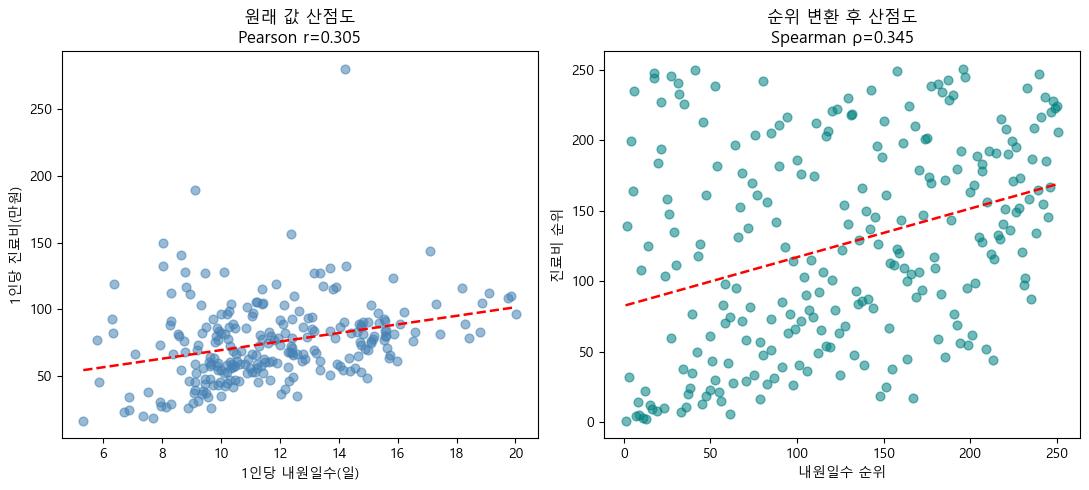

In [28]:
# 3. 산점도 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 원래 값 산점도
axes[0].scatter(x, y, alpha=0.55,
                color='steelblue', s=40)
z = np.polyfit(x, y, 1) # z[0]: 기울기(a), z[1]: y절편(b)
x_r = np.linspace(x.min(), x.max(), 200)
axes[0].plot(x_r, np.poly1d(z)(x_r),
             color='red', lw=1.8, ls='--')
axes[0].set_xlabel('1인당 내원일수(일)')
axes[0].set_ylabel('1인당 진료비(만원)')
axes[0].set_title(
    f'원래 값 산점도\nPearson r={r_p:.3f}')

# 순위 변환 산점도 (Spearman의 실체)
rx = rankdata(x); ry = rankdata(y)
axes[1].scatter(rx, ry, alpha=0.55,
                color='teal', s=40)
z2 = np.polyfit(rx, ry, 1)
x_r2 = np.linspace(rx.min(), rx.max(), 200)
axes[1].plot(x_r2, np.poly1d(z2)(x_r2),
             color='red', lw=1.8, ls='--')
axes[1].set_xlabel('내원일수 순위')
axes[1].set_ylabel('진료비 순위')
axes[1].set_title(
    f'순위 변환 후 산점도\nSpearman ρ={rho:.3f}')

plt.tight_layout()
plt.savefig('spearman.png', dpi=150)
plt.show()

In [29]:
# 4. 다변수 상관행렬
cols = ['1인당_진료비_만원',
        '1인당_내원일수',
        '보험자부담률', '환자수']

# Spearman 상관행렬
corr_sp = df[cols].corr(
    method='spearman').round(3)
print('\nSpearman 상관행렬:')
print(corr_sp)


Spearman 상관행렬:
            1인당_진료비_만원  1인당_내원일수  보험자부담률    환자수
1인당_진료비_만원       1.000     0.345   0.272  0.501
1인당_내원일수         0.345     1.000   0.077 -0.328
보험자부담률           0.272     0.077   1.000 -0.067
환자수              0.501    -0.328  -0.067  1.000


In [30]:
corr_sp

,1인당_진료비_만원,1인당_내원일수,보험자부담률,환자수
1인당_진료비_만원,1.000,0.345,0.272,0.501
1인당_내원일수,0.345,1.000,0.077,-0.328
보험자부담률,0.272,0.077,1.000,-0.067
환자수,0.501,-0.328,-0.067,1.000


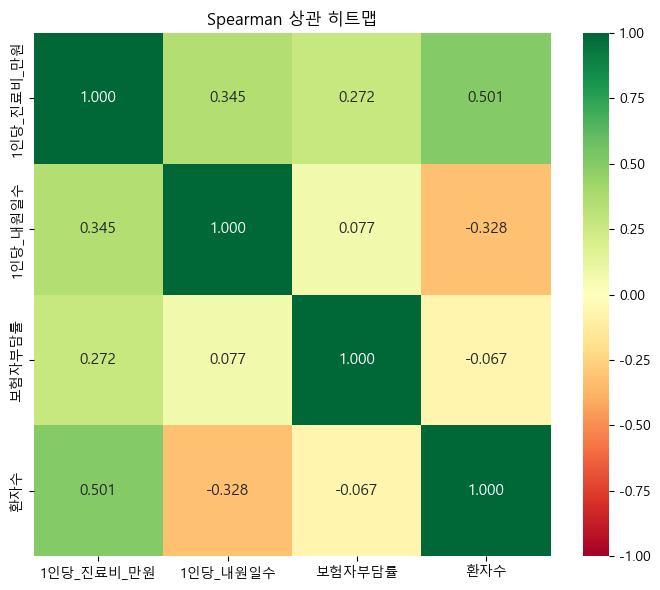

In [33]:
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_sp, annot=True,
            fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'size':11})
ax.set_title('Spearman 상관 히트맵')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150)
plt.show()

> **<결과살펴보기>**<br>
>**Spearman ρ** (내원일수↔진료비) : +0.345 <br>
양의 상관 — 내원일수 길수록 진료비 높음<br>
중간 강도 (0.2~0.4)<br>
>**p값** : <0.0001 - 통계적으로 유의 (n=251)<br>
우연에 의한 상관이 아님<br>
>**Pearson r** (비교용) : 0.305<br>
Spearman보다 낮음 - 이상치(화순군)의 영향<br>
>**환자수↔진료비 ρ** : +0.501<br>
가장 강한 상관 - 회귀모델 핵심 투입변수<br>

>**내원일수는 중증도의 간접 지표**<br>
ρ=0.345(p<0.0001)는 내원일수가 길수록 1인당 진료비가 높아지는 경향을 보입니다. 이는 입원 위주의 중증 진료일수록 비용이 높아지는 구조를 반영합니다. 화순군·익산시처럼 내원일수가 긴 거점병원 지역이 진료비도 높은 이유입니다.<br>

>**상관관계 ≠ 인과관계**<br>
ρ=0.345는 '내원일수가 진료비를 높인다'는 인과관계가 아닙니다. 두 변수 모두 '중증 환자 비중'이라는 제3의 변수에 의해 움직이는 것일 수 있습니다. 인과관계를 주장하려면 회귀분석과 도메인 지식이 필요합니다.<br>

>**차트 읽기**<br>
> 1. 산점도 + 추세선 — 관계 방향과 강도<br>
점들이 오른쪽 위 방향으로 흩어져 있으면 양의 상관입니다. 이상치가 추세선에서 벗어나 있지만 패턴을 크게 무너뜨리지 않습니다. 추세선 기울기가 완만하고 점들이 선 주변에 많이 퍼져 있으면 ρ가 낮은 중간 상관입니다. 점들이 추세선에 빽빽하게 몰리면 강한 상관입니다.<br>

> 2. 순위 변환 산점도 — Spearman의 실제 계산 근거<br>
원래 값을 순위로 바꾼 뒤 산점도를 그린 것입니다. 극단적 이상치(화순군)가 251위 한 점으로 처리되어 더 이상 튀어나오지 않습니다. 이 순위 산점도에서의 선형 상관이 바로 Spearman ρ입니다. 원래 값 산점도보다 점들이 더 고르게 퍼져 있는 것이 특징입니다.<br>

> 3. Spearman 상관 히트맵<br>
짙은 초록이 강한 양의 상관, 짙은 빨강이 강한 음의 상관입니다. 대각선은 자기 자신(ρ=1.0)이므로 짙은 초록입니다. 환자수↔진료비(ρ=0.50)가 가장 강한 양의 상관이고, 내원일수↔환자수(ρ=-0.33)는 중간 음의 상관입니다. 이 히트맵이 4단계 회귀모델에서 어떤 변수를 투입할지 결정하는 데 쓰입니다.<br>
종속변수(1인당_진료비)와 상관이 높은 변수를 투입합니다. 환자수(ρ=0.50)와 내원일수(ρ=0.35)가 후보입니다. 단, 환자수↔내원일수(ρ=-0.33)처럼 독립변수끼리 상관이 있으면 '다중공선성'을 주의해야 합니다.<br>

### 3.7 [종합] 통계 검정 결과 요약 및 모델링 전략 수립
앞선 5가지 검정 결과를 바탕으로 4단계 모델링(회귀 분석)의 설계도를 작성합니다.
- 종속 변수: 로그 변환 적용
- 독립 변수: 환자 수, 내원일수, 강원도 더미 변수 등 포함

>**메모**<br>
>**Spearman 결과**<br>
내원일수↔진료비 ρ=0.345(p<0.001)로 유의한 중간 강도의 양의 상관입니다. 환자수↔진료비(ρ=0.501)가 더 강하고, 보험자부담률↔진료비(ρ=0.272)도 유의합니다.<br>
>**Pearson(0.305) vs Spearman(0.345)**
차이의 의미가 중요합니다. 차이가 0.04 나는 것은 화순군처럼 극단적 이상치가 Pearson을 낮추고 있다는 신호입니다. 비모수 방법인 Spearman이 이 데이터에서 더 신뢰할 수 있는 수치입니다.<br>
5개 검정을 통해 발견한 것들이 회귀모델의 설계도가 됩니다.<br>

| 번호 | 검정 결과 | 회귀모델 반영 |
| :--- | :--- | :--- |
| 1 | 왜도 1.619 (검정 01) | 종속변수 → log(1인당_진료비) |
| 2 | 환자수 ρ=0.501 (검정 05) | 독립변수 투입 |
| 3 | 내원일수 ρ=0.345 (검정 05) | 독립변수 투입 |
| 4 | 강원도만 유의 (검정 04) | 강원도 더미변수 투입 |

# 분석 흐름 및 회귀모델 도출 근거 정리

---

### 분석 단계별 흐름 (Process Flow)

**01. Shapiro-Wilk 정규성 검정** — *“데이터의 분포 확인 및 검정 방법 선택”*
> - **결과:** $p < 0.0001$, 왜도($Skewness$) = $1.619$
> - **의미:** 정규성 기각 → **비모수 검정** 채택 및 종속변수 **로그 변환($log$)** 필요성 확인

**02. Mann-Whitney U 검정** — *“광역시 vs 비광역시 차이 비교”*
> - **결과:** $U=8,176, p=0.004$, 효과 크기 $r=0.18$ (소~중)
> - **의미:** 통계적 차이는 있으나 효과가 작음 → 시도 구분보다 상세한 지역 특성이 더 중요할 수 있음

**03. Kruskal-Wallis 검정** — *“17개 시도 간의 유의미한 차이 확인”*
> - **결과:** $H=30.885, p=0.014$, $\eta^2=0.064$ (중간 효과)
> - **의미:** 지역 간 차이 존재. 특히 **강원도**의 평균 순위(65.1)가 전체 평균(126)과 큰 괴리를 보임

**04. Dunn 사후검정** — *“구체적인 차이 발생 지역 식별”*
> - **결과:** 136쌍 중 3쌍만 유의 (강원↔서울, 강원↔경남, 강원↔부산)
> - **의미:** 강원도를 제외한 타 시도 간에는 차이가 거의 없음 → **강원도 의료 접근성**이 핵심 변수임을 시사

**05. Spearman 상관분석** — *“진료비와 연관된 독립변수 탐색”*
> - **결과:** 환자수($\rho=0.501$), 내원일수($\rho=0.345$), 보험자부담률($\rho=0.272$) 모두 $p < 0.001$
> - **의미:** 상관관계가 높은 변수들을 선별하여 회귀모델의 독립변수 후보군으로 선정

---

### 회귀모델 반영 결과 (Model Synthesis)

| 분류 | 검정 근거 | 모델 반영 사항 | 비고 |
| :--- | :--- | :--- | :--- |
| **종속 변수** | 왜도 1.619 (검정 01) | **$log$(1인당_진료비)** | 정규성 보정 |
| **핵심 독립변수** | 환자수 $\rho=0.501$ (검정 05) | **독립변수 투입** | 가장 강한 상관관계 |
| **보조 독립변수** | 내원일수 $\rho=0.345$ (검정 05) | **독립변수 투입** | 중증도 대리 지표 |
| **지역 통제** | Dunn 검정 유의성 (검정 04) | **강원도 더미변수** | 지역 특수성 통제 |

> **최종 결론:** <br>
> 본 모델은 데이터의 비정규성을 해결하기 위해 **로그 변환**을 수행하였으며, 상관분석과 사후검정에서 유의미하게 나타난 **환자수, 내원일수, 강원도 지역성**을 핵심 변수로 구성함.